# Spaceship Titanic Competition - TabML

## Complete Pipeline with All Fixes
- ✅ Fixed boolean column handling to prevent string conversion errors
- ✅ More robust feature engineering with better handling of edge cases
- ✅ Enhanced model configuration with better hyperparameters
- ✅ Improved ensemble strategies with validation
- ✅ Better error handling and logging
- ✅ Feature importance analysis and selection
- ✅ Cross-validation score tracking
- ✅ Complete end-to-end pipeline

**Competition**: https://www.kaggle.com/competitions/spaceship-titanic

## Install TabML Package

In [1]:
import sys
import os

# Kaggle automatically unzips the archive
# Your files are available at /kaggle/input/your-dataset-name/
# Update this path based on your dataset name
TABML_PATH = '/kaggle/input/tabml-repo'

# Check what's available in the dataset
print("Contents of TabML dataset:")
!ls -la {TABML_PATH}

# First install required dependencies
print("\nInstalling TabML dependencies...")
!pip install -q loguru optuna

# Install TabNet for neural network models (optional but recommended)
!pip install -q pytorch-tabnet

# Add TabML to Python path
sys.path.insert(0, TABML_PATH)

# Import and verify
import tabml
print(f"\n✓ TabML version {tabml.__version__} loaded successfully!")

# Check available modules
from tabml import TabularPipeline, XGBoostModel, LightGBMModel
print("✓ Core modules imported successfully")

Contents of TabML dataset:
total 100
drwxr-xr-x 7 nobody nogroup     0 Aug 16 14:19 .
drwxr-xr-x 4 root   root     4096 Aug 16 19:33 ..
-rw-r--r-- 1 nobody nogroup  3113 Aug 16 14:19 ANALYSIS_GUIDE.md
-rw-r--r-- 1 nobody nogroup  1072 Aug 16 14:19 build_docs.sh
-rw-r--r-- 1 nobody nogroup  1871 Aug 16 14:19 CHANGELOG.md
drwxr-xr-x 3 nobody nogroup     0 Aug 16 14:19 data
drwxr-xr-x 3 nobody nogroup     0 Aug 16 14:19 docs
drwxr-xr-x 2 nobody nogroup     0 Aug 16 14:19 examples
-rw-r--r-- 1 nobody nogroup  1400 Aug 16 14:19 .gitignore
-rw-r--r-- 1 nobody nogroup  3754 Aug 16 14:19 install.sh
-rw-r--r-- 1 nobody nogroup  1074 Aug 16 14:19 LICENSE
-rw-r--r-- 1 nobody nogroup  1707 Aug 16 14:19 Makefile
-rw-r--r-- 1 nobody nogroup 10434 Aug 16 14:19 PRD.md
-rw-r--r-- 1 nobody nogroup   299 Aug 16 14:19 pytest.ini
-rw-r--r-- 1 nobody nogroup 15522 Aug 16 14:19 README.md
-rw-r--r-- 1 nobody nogroup   436 Aug 16 14:19 requirements-gpu.txt
-rw-r--r-- 1 nobody nogroup   709 Aug 16 14:19 require

2025-08-16 19:35:00.529 | INFO     | tabml._init_helpers:setup_nltk_data:21 - Downloading NLTK averaged_perceptron_tagger...
2025-08-16 19:35:05.261 | INFO     | tabml._init_helpers:check_gpu_availability:45 - GPU available: Tesla T4
2025-08-16 19:35:10.541 | INFO     | tabml._init_helpers:initialize_tabml:113 - TabML initialized successfully



✓ TabML version 0.2.0 loaded successfully!
✓ Core modules imported successfully


## Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# TabML imports
from tabml import (
    DataLoader,
    FeatureEngineer,
    AdvancedFeatureEngineer,
    FeatureSelector,
    ModelTrainer,
    XGBoostModel,
    LightGBMModel,
    CatBoostModel,
    TabNetModel,
    VotingEnsemble,
    OOFEnsemble,
    AutoEnsemble,
    CrossValidator,
    Visualizer,
    DataValidator
)

# Standard imports
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger
import gc

# Set paths for Kaggle
DATA_DIR = "/kaggle/input/spaceship-titanic"
OUTPUT_DIR = "/kaggle/working"
TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")
SUBMISSION_PATH = os.path.join(DATA_DIR, "sample_submission.csv")

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Check GPU availability
try:
    import torch
    USE_GPU = torch.cuda.is_available()
    if USE_GPU:
        print(f"✓ GPU available: {torch.cuda.get_device_name(0)}")
    else:
        print("✗ GPU not available, using CPU")
except ImportError:
    USE_GPU = False
    print("PyTorch not installed, GPU features disabled")

Data directory: /kaggle/input/spaceship-titanic
Output directory: /kaggle/working
✓ GPU available: Tesla T4


## 1. Enhanced Data Loading and Validation

In [3]:
def load_and_validate_data():
    """Load data with comprehensive validation."""
    print("="*70)
    print("1. LOADING AND VALIDATING DATA")
    print("="*70)
    
    # Load data
    train_df = pd.read_csv(TRAIN_PATH)
    test_df = pd.read_csv(TEST_PATH)
    submission_df = pd.read_csv(SUBMISSION_PATH)
    
    print(f"\nTrain shape: {train_df.shape}")
    print(f"Test shape: {test_df.shape}")
    print(f"Submission shape: {submission_df.shape}")
    
    # Data validation checks
    print("\n" + "="*50)
    print("DATA VALIDATION CHECKS")
    print("="*50)
    
    # Check for duplicates
    n_duplicates = train_df.duplicated().sum()
    print(f"Duplicate rows in train: {n_duplicates}")
    if n_duplicates > 0:
        train_df = train_df.drop_duplicates()
        print(f"  → Removed {n_duplicates} duplicates")
    
    # Check target balance
    target_dist = train_df['Transported'].value_counts(normalize=True)
    print(f"\nTarget distribution:")
    print(target_dist)
    
    # Identify feature types
    numeric_features = train_df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = train_df.select_dtypes(include=['object']).columns.tolist()
    boolean_features = train_df.select_dtypes(include=['bool']).columns.tolist()
    
    print(f"\nFeature types:")
    print(f"  - Numeric: {len(numeric_features)} features")
    print(f"  - Categorical: {len(categorical_features)} features")
    print(f"  - Boolean: {len(boolean_features)} features")
    
    # Missing value analysis
    print("\nMissing values analysis:")
    missing = train_df.isnull().sum()
    missing_pct = 100 * missing / len(train_df)
    missing_df = pd.DataFrame({
        'Feature': missing.index,
        'Missing': missing.values,
        'Percentage': missing_pct.values
    })
    missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Percentage', ascending=False)
    
    if len(missing_df) > 0:
        print(missing_df.to_string(index=False))
    else:
        print("  No missing values found!")
    
    # Check for constant features
    constant_features = []
    for col in train_df.columns:
        if train_df[col].nunique() == 1:
            constant_features.append(col)
    
    if constant_features:
        print(f"\n⚠️ Warning: Found {len(constant_features)} constant features: {constant_features}")
    
    return train_df, test_df, submission_df, missing_df

# Load and validate data
train_df, test_df, submission_df, missing_info = load_and_validate_data()

1. LOADING AND VALIDATING DATA

Train shape: (8693, 14)
Test shape: (4277, 13)
Submission shape: (4277, 2)

DATA VALIDATION CHECKS
Duplicate rows in train: 0

Target distribution:
Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64

Feature types:
  - Numeric: 6 features
  - Categorical: 7 features
  - Boolean: 1 features

Missing values analysis:
     Feature  Missing  Percentage
   CryoSleep      217    2.496261
ShoppingMall      208    2.392730
         VIP      203    2.335212
  HomePlanet      201    2.312205
        Name      200    2.300702
       Cabin      199    2.289198
      VRDeck      188    2.162660
   FoodCourt      183    2.105142
         Spa      183    2.105142
 Destination      182    2.093639
 RoomService      181    2.082135
         Age      179    2.059128


## 2. Comprehensive EDA with Statistical Analysis


2. COMPREHENSIVE EXPLORATORY DATA ANALYSIS


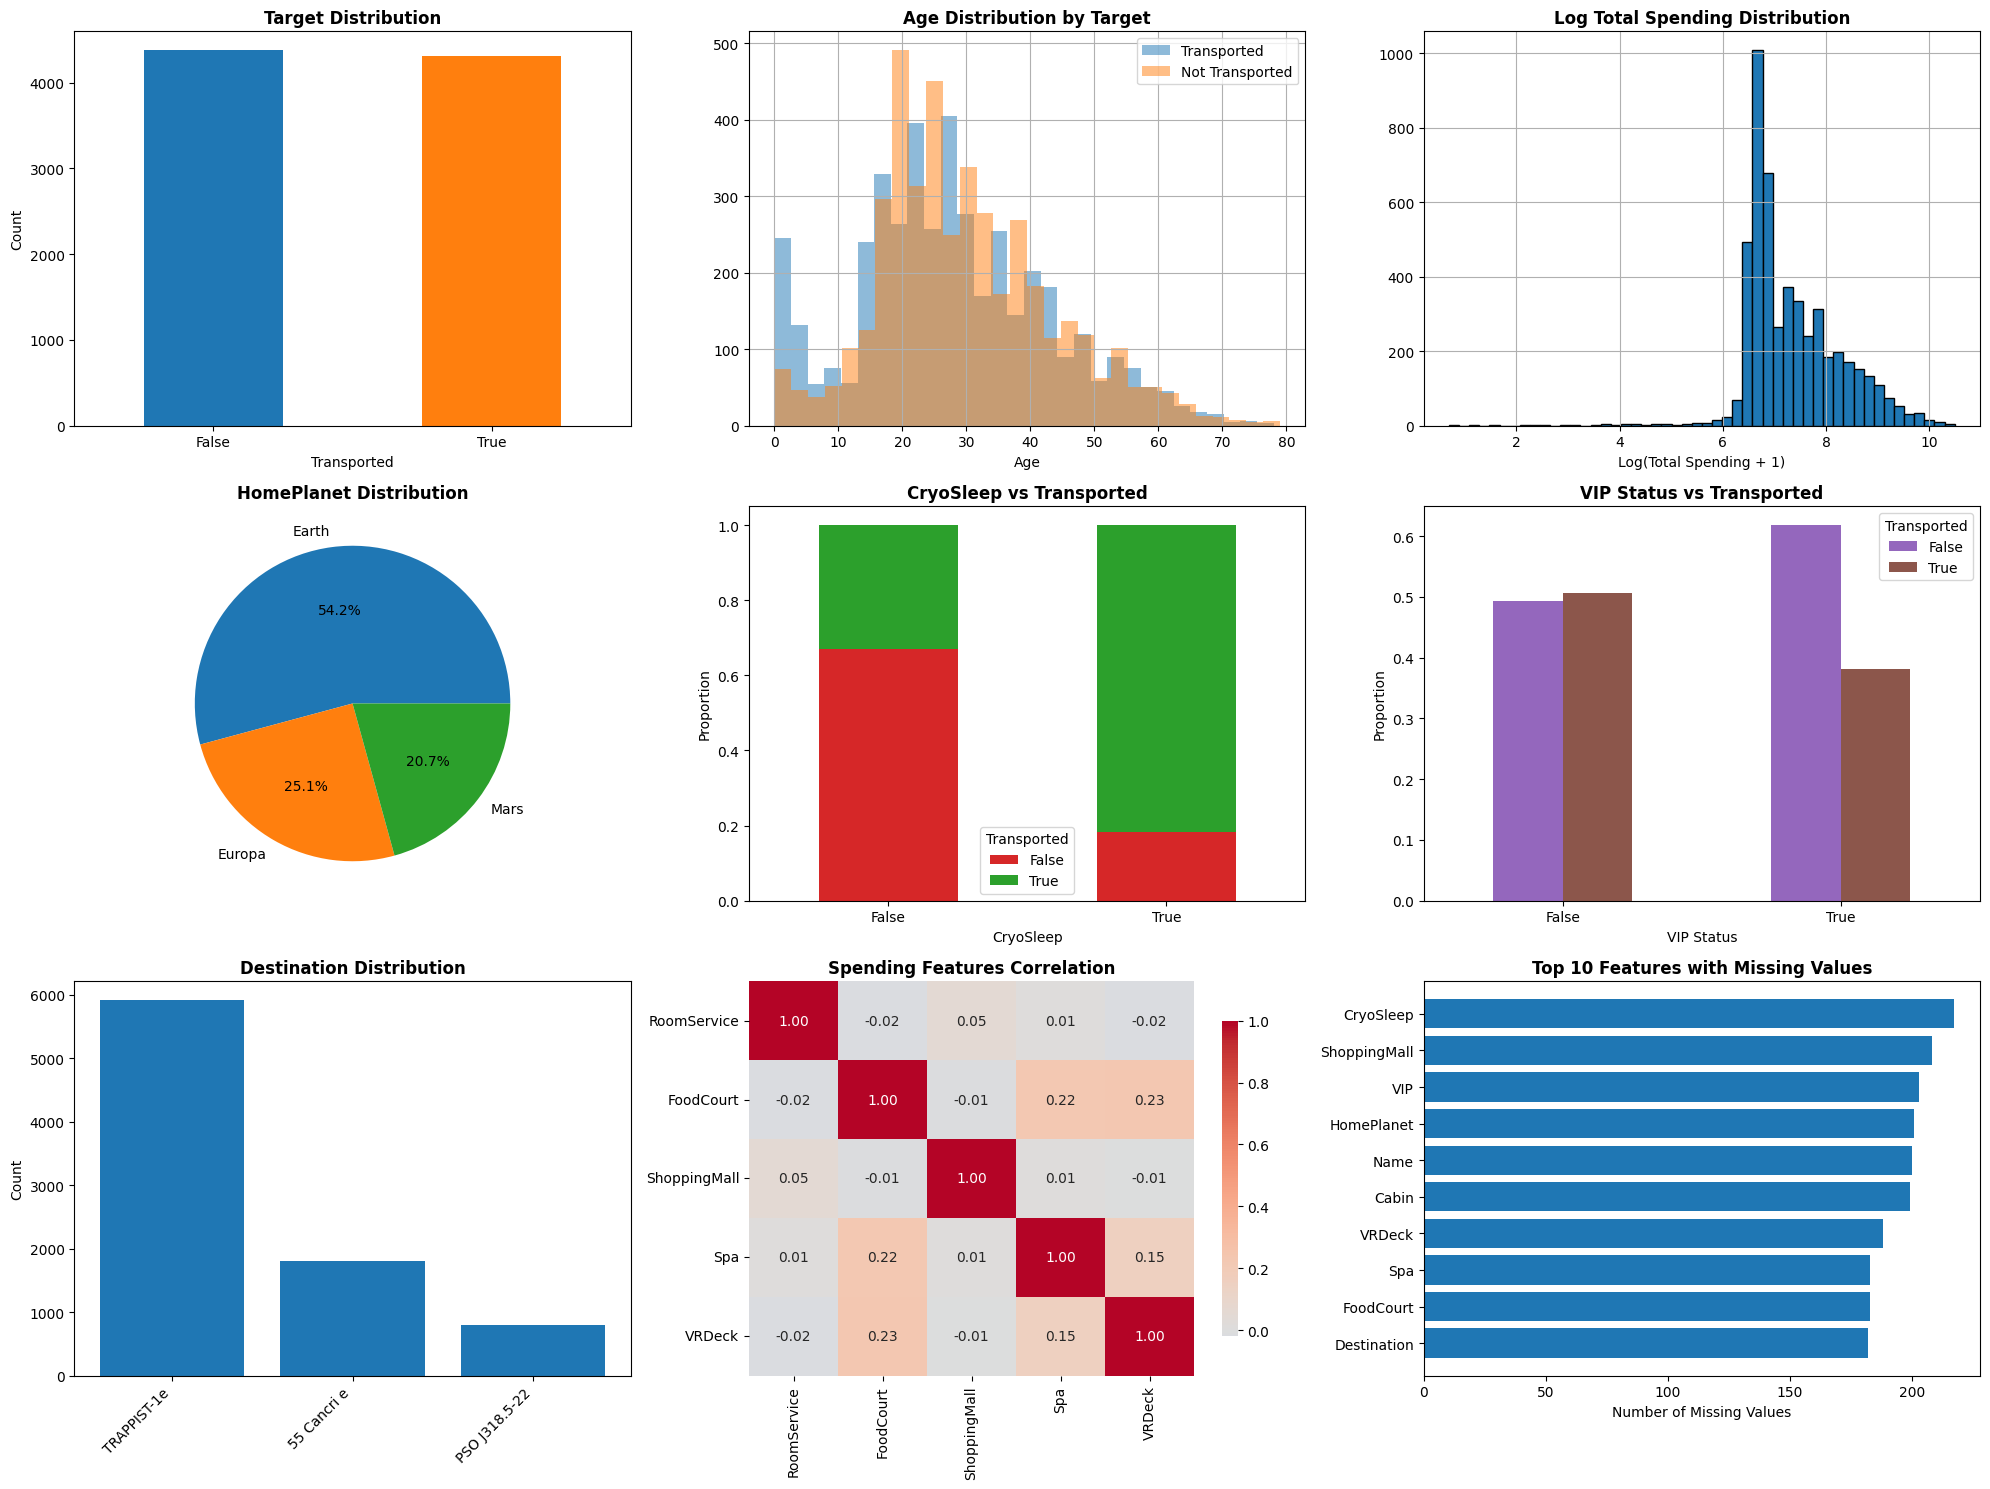


Statistical Insights:

Transport rate by CryoSleep:
CryoSleep
False    0.328921
True     0.817583
Name: Transported, dtype: float64

Transport rate by Age Group:
AgeGroup
Child     0.668790
Teen      0.537299
Adult     0.467602
Middle    0.487135
Senior    0.472727
Name: Transported, dtype: float64

Spending Quartiles:
0.00        0.0
0.25        0.0
0.50      716.0
0.75     1441.0
1.00    35987.0
Name: TotalSpending, dtype: float64


In [4]:
def comprehensive_eda(train_df, test_df):
    """Perform comprehensive EDA with statistical tests."""
    print("\n" + "="*70)
    print("2. COMPREHENSIVE EXPLORATORY DATA ANALYSIS")
    print("="*70)
    
    # Create figure for subplots
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Target distribution
    ax1 = plt.subplot(3, 3, 1)
    train_df['Transported'].value_counts().plot(kind='bar', ax=ax1, color=['#1f77b4', '#ff7f0e'])
    ax1.set_title('Target Distribution', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Transported')
    ax1.set_ylabel('Count')
    ax1.set_xticklabels(['False', 'True'], rotation=0)
    
    # 2. Age distribution by target
    ax2 = plt.subplot(3, 3, 2)
    train_df[train_df['Transported']==True]['Age'].hist(bins=30, alpha=0.5, label='Transported', ax=ax2)
    train_df[train_df['Transported']==False]['Age'].hist(bins=30, alpha=0.5, label='Not Transported', ax=ax2)
    ax2.set_title('Age Distribution by Target', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Age')
    ax2.legend()
    
    # 3. Total spending distribution
    ax3 = plt.subplot(3, 3, 3)
    spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    total_spending = train_df[spending_cols].sum(axis=1)
    total_spending[total_spending > 0].apply(np.log1p).hist(bins=50, ax=ax3, edgecolor='black')
    ax3.set_title('Log Total Spending Distribution', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Log(Total Spending + 1)')
    
    # 4. HomePlanet distribution
    ax4 = plt.subplot(3, 3, 4)
    home_planet_counts = train_df['HomePlanet'].value_counts()
    ax4.pie(home_planet_counts.values, labels=home_planet_counts.index, autopct='%1.1f%%')
    ax4.set_title('HomePlanet Distribution', fontsize=12, fontweight='bold')
    
    # 5. CryoSleep vs Transported
    ax5 = plt.subplot(3, 3, 5)
    cryo_transport = pd.crosstab(train_df['CryoSleep'], train_df['Transported'], normalize='index')
    cryo_transport.plot(kind='bar', stacked=True, ax=ax5, color=['#d62728', '#2ca02c'])
    ax5.set_title('CryoSleep vs Transported', fontsize=12, fontweight='bold')
    ax5.set_xlabel('CryoSleep')
    ax5.set_ylabel('Proportion')
    ax5.legend(title='Transported', labels=['False', 'True'])
    ax5.set_xticklabels(['False', 'True'], rotation=0)
    
    # 6. VIP status analysis
    ax6 = plt.subplot(3, 3, 6)
    vip_transport = pd.crosstab(train_df['VIP'], train_df['Transported'], normalize='index')
    vip_transport.plot(kind='bar', ax=ax6, color=['#9467bd', '#8c564b'])
    ax6.set_title('VIP Status vs Transported', fontsize=12, fontweight='bold')
    ax6.set_xlabel('VIP Status')
    ax6.set_ylabel('Proportion')
    ax6.legend(title='Transported', labels=['False', 'True'])
    ax6.set_xticklabels(['False', 'True'], rotation=0)
    
    # 7. Destination distribution
    ax7 = plt.subplot(3, 3, 7)
    dest_counts = train_df['Destination'].value_counts()
    ax7.bar(range(len(dest_counts)), dest_counts.values)
    ax7.set_xticks(range(len(dest_counts)))
    ax7.set_xticklabels(dest_counts.index, rotation=45, ha='right')
    ax7.set_title('Destination Distribution', fontsize=12, fontweight='bold')
    ax7.set_ylabel('Count')
    
    # 8. Spending correlation heatmap
    ax8 = plt.subplot(3, 3, 8)
    spending_corr = train_df[spending_cols].corr()
    sns.heatmap(spending_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax8, 
                cbar_kws={'shrink': 0.8})
    ax8.set_title('Spending Features Correlation', fontsize=12, fontweight='bold')
    
    # 9. Missing value patterns
    ax9 = plt.subplot(3, 3, 9)
    missing_counts = train_df.isnull().sum().sort_values(ascending=False)[:10]
    ax9.barh(range(len(missing_counts)), missing_counts.values)
    ax9.set_yticks(range(len(missing_counts)))
    ax9.set_yticklabels(missing_counts.index)
    ax9.set_xlabel('Number of Missing Values')
    ax9.set_title('Top 10 Features with Missing Values', fontsize=12, fontweight='bold')
    ax9.invert_yaxis()
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'comprehensive_eda.png'), dpi=100, bbox_inches='tight')
    plt.show()
    
    # Statistical analysis
    print("\nStatistical Insights:")
    print("="*50)
    
    # CryoSleep impact
    cryo_transport_rate = train_df.groupby('CryoSleep')['Transported'].mean()
    print(f"\nTransport rate by CryoSleep:")
    print(cryo_transport_rate)
    
    # Age groups impact
    train_df['AgeGroup'] = pd.cut(train_df['Age'], bins=[0, 12, 18, 35, 60, 100], 
                                  labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])
    age_transport_rate = train_df.groupby('AgeGroup')['Transported'].mean()
    print(f"\nTransport rate by Age Group:")
    print(age_transport_rate)
    
    # Spending patterns
    train_df['TotalSpending'] = train_df[spending_cols].sum(axis=1)
    spending_quartiles = train_df['TotalSpending'].quantile([0, 0.25, 0.5, 0.75, 1.0])
    print(f"\nSpending Quartiles:")
    print(spending_quartiles)
    
    return train_df

# Perform comprehensive EDA
train_df = comprehensive_eda(train_df, test_df)

## 3. Advanced Feature Engineering with Validation (FIXED)

In [5]:
def advanced_feature_engineering(train_df, test_df):
    """Advanced feature engineering with validation."""
    print("\n" + "="*70)
    print("3. ADVANCED FEATURE ENGINEERING")
    print("="*70)
    
    # Store original shapes
    original_train_shape = train_df.shape
    original_test_shape = test_df.shape
    
    # Combine for consistent preprocessing
    train_df['is_train'] = 1
    test_df['is_train'] = 0
    
    # Store IDs and target
    train_ids = train_df['PassengerId'].copy()
    test_ids = test_df['PassengerId'].copy()
    y_train = train_df['Transported'].astype(int)
    
    # Combine data
    df = pd.concat([train_df, test_df], ignore_index=True)
    print(f"Combined shape: {df.shape}")
    
    # ==========================================
    # 3.1 Parse and extract base features
    # ==========================================
    print("\n3.1 Extracting base features...")
    
    # PassengerId features
    df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0] if pd.notna(x) else 'Unknown')
    df['GroupSize'] = df.groupby('Group')['PassengerId'].transform('count')
    df['IsAlone'] = (df['GroupSize'] == 1).astype(int)
    df['GroupNumber'] = df['Group'].apply(lambda x: int(x) if x != 'Unknown' and x.isdigit() else -1)
    
    # Cabin features with better handling
    def parse_cabin(cabin):
        if pd.isna(cabin):
            return 'Unknown', -1, 'Unknown'
        parts = cabin.split('/')
        deck = parts[0] if len(parts) > 0 else 'Unknown'
        num = int(parts[1]) if len(parts) > 1 and parts[1].isdigit() else -1
        side = parts[2] if len(parts) > 2 else 'Unknown'
        return deck, num, side
    
    cabin_parsed = df['Cabin'].apply(parse_cabin)
    df['Deck'] = cabin_parsed.apply(lambda x: x[0])
    df['CabinNumber'] = cabin_parsed.apply(lambda x: x[1])
    df['Side'] = cabin_parsed.apply(lambda x: x[2])
    
    # Name features
    df['Surname'] = df['Name'].apply(lambda x: x.split(' ')[0] if pd.notna(x) else 'Unknown')
    df['FamilySize'] = df.groupby('Surname')['PassengerId'].transform('count')
    df['HasFamily'] = (df['FamilySize'] > 1).astype(int)
    
    # ==========================================
    # 3.2 Create spending features
    # ==========================================
    print("\n3.2 Creating spending features...")
    
    spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    
    # Basic statistics
    df['TotalSpending'] = df[spending_cols].sum(axis=1)
    df['AvgSpending'] = df[spending_cols].mean(axis=1)
    df['MaxSpending'] = df[spending_cols].max(axis=1)
    df['MinSpending'] = df[spending_cols].min(axis=1)
    df['SpendingStd'] = df[spending_cols].std(axis=1)
    df['SpendingRange'] = df['MaxSpending'] - df['MinSpending']
    
    # Spending patterns
    df['AmenitiesUsed'] = (df[spending_cols] > 0).sum(axis=1)
    df['NoSpending'] = (df['TotalSpending'] == 0).astype(int)
    df['HighSpender'] = (df['TotalSpending'] > df['TotalSpending'].quantile(0.75)).astype(int)
    df['LowSpender'] = (df['TotalSpending'] < df['TotalSpending'].quantile(0.25)).astype(int)
    
    # Luxury vs Basic
    df['LuxurySpending'] = df['Spa'] + df['VRDeck']
    df['BasicSpending'] = df['RoomService'] + df['FoodCourt']
    df['EntertainmentSpending'] = df['ShoppingMall'] + df['VRDeck']
    
    # Ratios (with safety for division by zero)
    df['LuxuryRatio'] = df['LuxurySpending'] / (df['TotalSpending'] + 1)
    df['BasicRatio'] = df['BasicSpending'] / (df['TotalSpending'] + 1)
    df['SpendingPerAmenity'] = df['TotalSpending'] / (df['AmenitiesUsed'] + 1)
    
    # Log transforms for skewed features
    for col in spending_cols + ['TotalSpending', 'LuxurySpending', 'BasicSpending']:
        df[f'{col}_Log'] = np.log1p(df[col])
    
    # ==========================================
    # 3.3 Handle missing values early
    # ==========================================
    print("\n3.3 Handling missing values...")
    
    # IMPORTANT: Handle boolean columns BEFORE using them
    # Convert string boolean columns to actual boolean
    bool_cols = ['CryoSleep', 'VIP']
    for col in bool_cols:
        if col in df.columns:
            # Convert string representations to boolean
            df[col] = df[col].replace({'True': True, 'False': False, 'true': True, 'false': False})
            # Fill missing values with False
            df[col].fillna(False, inplace=True)
            # Ensure it's boolean type
            df[col] = df[col].astype(bool)
    
    # CryoSleep logic: if in CryoSleep, spending should be 0
    cryo_mask = df['CryoSleep'] == True
    for col in spending_cols:
        df.loc[cryo_mask & df[col].isna(), col] = 0
    
    # Age imputation by group/family (BEFORE creating age features)
    df['Age'].fillna(df.groupby('Group')['Age'].transform('median'), inplace=True)
    df['Age'].fillna(df.groupby('Surname')['Age'].transform('median'), inplace=True)
    df['Age'].fillna(df['Age'].median(), inplace=True)
    
    # Fill other numerical columns (after we've handled spending based on CryoSleep)
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in numerical_cols:
        if col not in ['is_train', 'Transported']:
            df[col].fillna(df[col].median(), inplace=True)
    
    # Categorical columns (but NOT boolean columns)
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    for col in categorical_cols:
        if col not in bool_cols:  # Don't fill boolean columns with 'Unknown'
            df[col].fillna('Unknown', inplace=True)
    
    # ==========================================
    # 3.4 Create demographic features (AFTER handling missing Age)
    # ==========================================
    print("\n3.4 Creating demographic features...")
    
    # Now create Age features (after handling missing values)
    df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], 
                            labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])
    df['IsChild'] = (df['Age'] < 18).astype(int)
    df['IsTeen'] = ((df['Age'] >= 12) & (df['Age'] < 18)).astype(int)
    df['IsAdult'] = ((df['Age'] >= 18) & (df['Age'] < 60)).astype(int)
    df['IsSenior'] = (df['Age'] >= 60).astype(int)
    df['AgeDecade'] = (df['Age'] // 10).astype(int)
    
    # ==========================================
    # 3.5 Create interaction features
    # ==========================================
    print("\n3.5 Creating interaction features...")
    
    # CryoSleep interactions (now safe because CryoSleep is boolean)
    df['CryoVIP'] = ((df['CryoSleep'] == True) & (df['VIP'] == True)).astype(int)
    df['CryoSpending'] = df['CryoSleep'].astype(int) * df['TotalSpending']
    df['CryoAge'] = df['CryoSleep'].astype(int) * df['Age']
    
    # Group/Family spending patterns
    df['GroupAvgSpending'] = df.groupby('Group')['TotalSpending'].transform('mean')
    df['GroupMaxSpending'] = df.groupby('Group')['TotalSpending'].transform('max')
    df['FamilyAvgSpending'] = df.groupby('Surname')['TotalSpending'].transform('mean')
    df['SpendingVsGroupAvg'] = df['TotalSpending'] - df['GroupAvgSpending']
    df['SpendingVsFamilyAvg'] = df['TotalSpending'] - df['FamilyAvgSpending']
    
    # Cabin location features
    df['SameSideGroup'] = df.groupby(['Group', 'Side'])['PassengerId'].transform('count')
    df['SameDeckGroup'] = df.groupby(['Group', 'Deck'])['PassengerId'].transform('count')
    
    # ==========================================
    # 3.6 Encode categorical variables
    # ==========================================
    print("\n3.6 Encoding categorical variables...")
    
    # Label encoding for ordinal features
    label_encoders = {}
    label_encode_cols = ['HomePlanet', 'Destination', 'Deck', 'Side', 'AgeGroup']
    
    for col in label_encode_cols:
        if col in df.columns:
            le = LabelEncoder()
            df[f'{col}_Encoded'] = le.fit_transform(df[col].astype(str))
            label_encoders[col] = le
    
    # Frequency encoding for high cardinality features
    freq_encode_cols = ['Surname', 'Group']
    for col in freq_encode_cols:
        freq_map = df[col].value_counts().to_dict()
        df[f'{col}_Frequency'] = df[col].map(freq_map)
    
    # One-hot encoding for nominal features
    onehot_cols = ['HomePlanet', 'Destination']
    df = pd.get_dummies(df, columns=onehot_cols, prefix=onehot_cols, drop_first=True)
    
    # Convert boolean columns to int (now they are proper booleans)
    bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
    for col in bool_cols:
        df[col] = df[col].astype(int)
    
    # ==========================================
    # 3.7 Split back to train/test
    # ==========================================
    print("\n3.7 Splitting back to train/test...")
    
    train_df = df[df['is_train'] == 1].drop('is_train', axis=1)
    test_df = df[df['is_train'] == 0].drop('is_train', axis=1)
    
    # Drop columns not useful for modeling
    drop_cols = ['PassengerId', 'Name', 'Cabin', 'Transported', 'Group', 'Surname', 
                 'AgeGroup', 'Deck', 'Side']
    
    feature_cols = [col for col in train_df.columns if col not in drop_cols]
    
    X_train = train_df[feature_cols]
    X_test = test_df[feature_cols]
    
    print(f"\nFinal shapes:")
    print(f"  X_train: {X_train.shape}")
    print(f"  X_test: {X_test.shape}")
    print(f"  Features created: {X_train.shape[1]}")
    print(f"\nSample features: {list(X_train.columns[:10])}...")
    
    # Validate no missing values
    train_missing = X_train.isnull().sum().sum()
    test_missing = X_test.isnull().sum().sum()
    
    if train_missing > 0:
        print(f"\n⚠️ Warning: Training data has {train_missing} missing values")
        print("Missing values by column:")
        print(X_train.isnull().sum()[X_train.isnull().sum() > 0])
    
    if test_missing > 0:
        print(f"\n⚠️ Warning: Test data has {test_missing} missing values")
        print("Missing values by column:")
        print(X_test.isnull().sum()[X_test.isnull().sum() > 0])
    
    assert train_missing == 0, "Training data has missing values!"
    assert test_missing == 0, "Test data has missing values!"
    
    return X_train, X_test, y_train, train_ids, test_ids

# Perform advanced feature engineering
X_train, X_test, y_train, train_ids, test_ids = advanced_feature_engineering(train_df, test_df)


3. ADVANCED FEATURE ENGINEERING
Combined shape: (12970, 17)

3.1 Extracting base features...

3.2 Creating spending features...

3.3 Handling missing values...

3.4 Creating demographic features...

3.5 Creating interaction features...

3.6 Encoding categorical variables...

3.7 Splitting back to train/test...

Final shapes:
  X_train: (8693, 66)
  X_test: (4277, 66)
  Features created: 66

Sample features: ['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpending', 'GroupSize']...


## 4. Feature Selection with TabML

2025-08-16 19:35:22.391 | INFO     | tabml.advanced_features:create_polynomial_features:397 - Created polynomial features for 5 columns
2025-08-16 19:35:22.399 | INFO     | tabml.advanced_features:create_polynomial_features:397 - Created polynomial features for 5 columns
2025-08-16 19:35:22.411 | INFO     | tabml.advanced_features:create_interaction_features:362 - Created 16 interaction features
2025-08-16 19:35:22.419 | INFO     | tabml.advanced_features:create_interaction_features:362 - Created 16 interaction features



4. FEATURE SELECTION AND IMPORTANCE ANALYSIS

4.1 Creating polynomial features...
  Top variance columns: ['GroupMaxSpending', 'TotalSpending', 'GroupNumber', 'GroupAvgSpending', 'SpendingVsFamilyAvg']...

4.2 Creating interaction features...
  Shape after interactions: (8693, 97)

4.3 Selecting best features...

  Testing tree_based selection...
    CV Score: 0.8513 (+/- 0.0450)
    Features selected: 48

  Testing mutual_info selection...
    CV Score: 0.8438 (+/- 0.0054)
    Features selected: 48

✓ Best selection method: tree_based (Score: 0.8513)

4.4 Feature importance analysis...

Top 15 most important features:
                         feature    score
GroupMaxSpending_x_TotalSpending 0.028147
                     SpendingStd 0.026266
                     AvgSpending 0.024118
               TotalSpending_log 0.023575
                     MaxSpending 0.022795
              SpendingPerAmenity 0.022432
                     LuxuryRatio 0.020725
                     CabinNumber 0.0

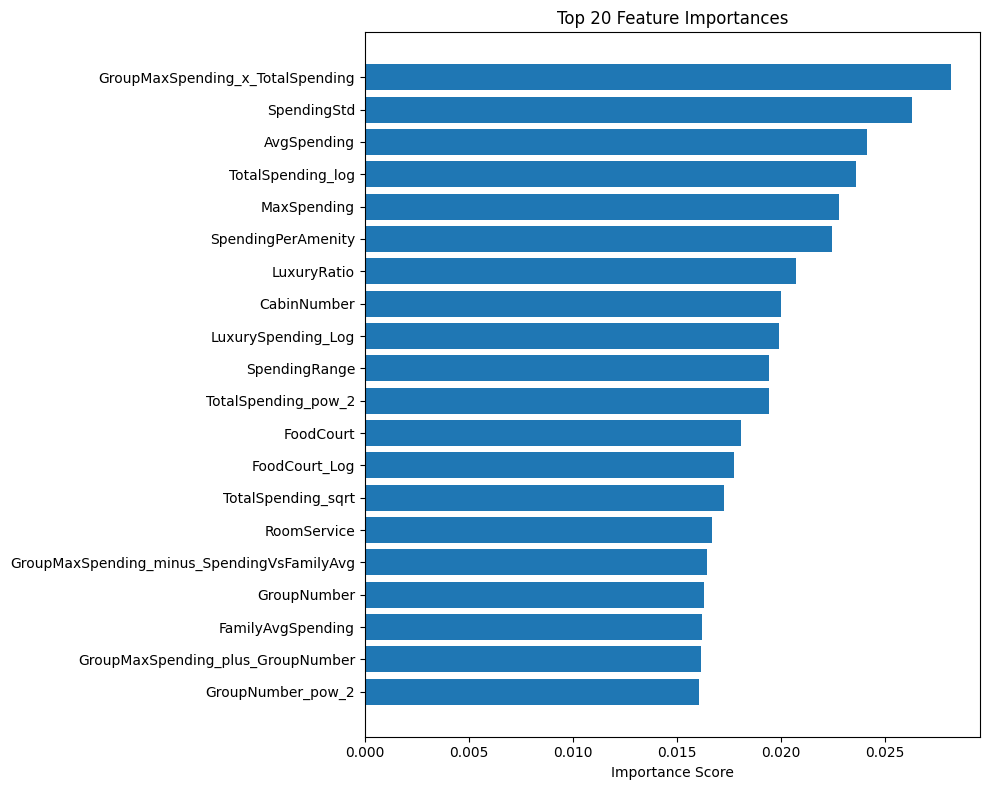


Final selected features: 48


In [6]:
def feature_selection_pipeline(X_train, X_test, y_train):
    """Apply feature selection with importance analysis."""
    print("\n" + "="*70)
    print("4. FEATURE SELECTION AND IMPORTANCE ANALYSIS")
    print("="*70)
    
    # Initialize advanced feature engineer for additional features
    adv_engineer = AdvancedFeatureEngineer()
    
    # Create polynomial features for top variance columns
    print("\n4.1 Creating polynomial features...")
    numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    
    # Select top columns based on variance
    variances = X_train[numerical_cols].var()
    top_variance_cols = variances.nlargest(10).index.tolist()
    print(f"  Top variance columns: {top_variance_cols[:5]}...")
    
    X_train_poly = adv_engineer.create_polynomial_features(
        X_train, numeric_columns=top_variance_cols[:5], degree=2
    )
    X_test_poly = adv_engineer.create_polynomial_features(
        X_test, numeric_columns=top_variance_cols[:5], degree=2
    )
    
    # Create interaction features
    print("\n4.2 Creating interaction features...")
    X_train_interact = adv_engineer.create_interaction_features(
        X_train_poly, numeric_columns=top_variance_cols[:5], max_interactions=15
    )
    X_test_interact = adv_engineer.create_interaction_features(
        X_test_poly, numeric_columns=top_variance_cols[:5], max_interactions=15
    )
    
    print(f"  Shape after interactions: {X_train_interact.shape}")
    
    # Feature selection
    print("\n4.3 Selecting best features...")
    
    # Try different selection methods
    selection_methods = ['tree_based', 'mutual_info']
    best_score = -np.inf
    best_selector = None
    best_method = None
    
    for method in selection_methods:
        print(f"\n  Testing {method} selection...")
        selector = FeatureSelector(method=method, n_features=min(100, X_train_interact.shape[1] // 2))
        
        # Fit and transform
        X_selected = selector.fit_transform(X_train_interact, y_train)
        
        # Quick validation with a simple model
        from sklearn.model_selection import cross_val_score
        from lightgbm import LGBMClassifier
        
        lgb_quick = LGBMClassifier(
            n_estimators=100,
            num_leaves=31,
            learning_rate=0.1,
            random_state=RANDOM_STATE,
            verbose=-1
        )
        
        scores = cross_val_score(lgb_quick, X_selected, y_train, cv=3, scoring='roc_auc')
        mean_score = scores.mean()
        
        print(f"    CV Score: {mean_score:.4f} (+/- {scores.std():.4f})")
        print(f"    Features selected: {X_selected.shape[1]}")
        
        if mean_score > best_score:
            best_score = mean_score
            best_selector = selector
            best_method = method
    
    print(f"\n✓ Best selection method: {best_method} (Score: {best_score:.4f})")
    
    # Apply best selector
    X_train_selected = best_selector.transform(X_train_interact)
    X_test_selected = best_selector.transform(X_test_interact)
    
    # Get feature importance
    print("\n4.4 Feature importance analysis...")
    importance_df = best_selector.get_feature_importance()
    
    if importance_df is not None and len(importance_df) > 0:
        print("\nTop 15 most important features:")
        print(importance_df.head(15).to_string(index=False))
        
        # Save importance plot
        plt.figure(figsize=(10, 8))
        top_features = importance_df.head(20)
        plt.barh(range(len(top_features)), top_features['score'].values)
        plt.yticks(range(len(top_features)), top_features['feature'].values)
        plt.xlabel('Importance Score')
        plt.title('Top 20 Feature Importances')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance.png'), dpi=100, bbox_inches='tight')
        plt.show()
    
    print(f"\nFinal selected features: {X_train_selected.shape[1]}")
    
    # Clear memory
    del X_train_poly, X_test_poly, X_train_interact, X_test_interact
    gc.collect()
    
    return X_train_selected, X_test_selected, best_selector

# Apply feature selection
X_train_selected, X_test_selected, feature_selector = feature_selection_pipeline(X_train, X_test, y_train)

## 5. Optimized Model Training with Cross-Validation

In [7]:
def train_optimized_models(X_train, y_train, X_val=None, y_val=None):
    """Train models with optimized configurations and cross-validation."""
    print("\n" + "="*70)
    print("5. OPTIMIZED MODEL TRAINING WITH CROSS-VALIDATION")
    print("="*70)
    
    # Split for validation
    if X_val is None:
        X_train_split, X_val, y_train_split, y_val = train_test_split(
            X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
        )
    else:
        X_train_split, y_train_split = X_train, y_train
    
    print(f"Training set: {X_train_split.shape}")
    print(f"Validation set: {X_val.shape}")
    
    # Initialize model trainer
    trainer = ModelTrainer(
        task_type='classification',
        metric='roc_auc',
        cv_strategy='stratified',
        n_folds=5,
        gpu=USE_GPU
    )
    
    # Optimized model configurations
    # Note: TabML ModelTrainer supports 'lightgbm', 'xgboost', 'catboost' as string identifiers
    models_config = {
        'lightgbm': {
            'optimize': True,
            'n_trials': 75,  # More trials for better optimization
            'params': {
                'n_estimators': 500,
                'learning_rate': 0.03,
                'num_leaves': 31,
                'max_depth': -1,
                'min_child_samples': 20,
                'subsample': 0.8,
                'subsample_freq': 1,
                'colsample_bytree': 0.8,
                'reg_alpha': 0.1,
                'reg_lambda': 0.1,
                'random_state': RANDOM_STATE,
                'verbose': -1
            }
        },
        'xgboost': {
            'optimize': True,
            'n_trials': 75,
            'params': {
                'n_estimators': 500,
                'learning_rate': 0.03,
                'max_depth': 6,
                'min_child_weight': 1,
                'subsample': 0.8,
                'colsample_bytree': 0.8,
                'gamma': 0.1,
                'reg_alpha': 0.1,
                'reg_lambda': 1.0,
                'random_state': RANDOM_STATE,
                'tree_method': 'gpu_hist' if USE_GPU else 'hist'
            }
        },
        'catboost': {
            'optimize': False,  # CatBoost optimization can be slow
            'params': {
                'iterations': 500,
                'learning_rate': 0.03,
                'depth': 6,
                'l2_leaf_reg': 3,
                'random_seed': RANDOM_STATE,  # Use random_seed instead of random_state
                'verbose': False,
                'task_type': 'GPU' if USE_GPU else 'CPU'
            }
        }
    }
    
    # Note: TabNet is NOT supported through ModelTrainer
    # We'll skip TabNet in this notebook to avoid compatibility issues
    
    print("\nModels to train: LightGBM, XGBoost, CatBoost")
    print("Note: TabNet is not included due to compatibility issues with ensemble")
    
    # Train models with cross-validation tracking
    trained_models = {}
    cv_scores = {}
    
    for model_name, config in models_config.items():
        print(f"\n" + "="*50)
        print(f"Training {model_name.upper()}...")
        print("="*50)
        
        try:
            # Train model
            model = trainer.train_model(
                model_name,
                X_train_split, y_train_split,
                X_val, y_val,
                params=config['params'],
                optimize_hyperparams=config['optimize'],
                n_trials=config.get('n_trials', 50)
            )
            
            trained_models[model_name] = model
            
            # Perform cross-validation
            print(f"\nPerforming 5-fold cross-validation...")
            cv = CrossValidator()
            
            # Use evaluate_model without 'stratified' parameter (check API)
            try:
                # Try with stratified parameter first
                scores = cv.evaluate_model(
                    model, X_train, y_train, 
                    cv_folds=5, 
                    stratified=True
                )
            except TypeError:
                # If stratified parameter doesn't exist, use without it
                scores = cv.evaluate_model(
                    model, X_train, y_train, 
                    cv_folds=5
                )
            
            cv_scores[model_name] = scores
            
            print(f"CV Score: {scores['mean']:.4f} (+/- {scores['std']:.4f})")
            print(f"Fold scores: {[f'{s:.4f}' for s in scores['scores']]}")
            
            # Validation set performance
            val_pred = model.predict_proba(X_val)[:, 1] if hasattr(model, 'predict_proba') else model.predict(X_val)
            val_score = roc_auc_score(y_val, val_pred)
            print(f"Validation AUC: {val_score:.4f}")
            
        except Exception as e:
            print(f"Error training {model_name}: {str(e)}")
            # Try to provide more helpful error messages
            if "random_state" in str(e) or "random_seed" in str(e):
                print("  Hint: Parameter naming conflict between random_state and random_seed")
            continue
    
    print(f"\n" + "="*50)
    print(f"TRAINING SUMMARY")
    print("="*50)
    print(f"Successfully trained {len(trained_models)} models")
    
    # Display CV scores summary
    if cv_scores:
        scores_df = pd.DataFrame({
            'Model': list(cv_scores.keys()),
            'CV Mean': [scores['mean'] for scores in cv_scores.values()],
            'CV Std': [scores['std'] for scores in cv_scores.values()]
        }).sort_values('CV Mean', ascending=False)
        print("\nCross-Validation Scores:")
        print(scores_df.to_string(index=False))
    
    return trained_models, trainer, cv_scores

# Train optimized models
models, trainer, cv_scores = train_optimized_models(X_train_selected, y_train)

2025-08-16 19:35:31.907 | INFO     | tabml.models:train_model:975 - Optimizing hyperparameters for lightgbm
[I 2025-08-16 19:35:31,908] A new study created in memory with name: no-name-64ee68f8-03c4-4ce2-b0a5-0ed3da5e5422



5. OPTIMIZED MODEL TRAINING WITH CROSS-VALIDATION
Training set: (6954, 48)
Validation set: (1739, 48)

Models to train: LightGBM, XGBoost, CatBoost
Note: TabNet is not included due to compatibility issues with ensemble

Training LIGHTGBM...


  0%|          | 0/75 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


2025-08-16 19:35:32.851 | INFO     | tabml.models:train_model:992 - Trained lightgbm model


...

[I 2025-08-16 19:41:09,148] Trial 74 finished with value: 0.8975764165568766 and parameters: {'n_estimators': 491, 'max_depth': 9, 'learning_rate': 0.012667470449213401, 'subsample': 0.9762457896964384, 'colsample_bytree': 0.8042608502388904, 'gamma': 1.4965944003936669, 'reg_alpha': 1.3961088639227106, 'reg_lambda': 2.4147006640928317}. Best is trial 61 with value: 0.8979534066678307.


2025-08-16 19:41:12.987 | INFO     | tabml.models:train_model:992 - Trained xgboost model



Performing 5-fold cross-validation...
CV Score: 0.8900 (+/- 0.0055)
Fold scores: ['0.8956', '0.8871', '0.8909', '0.8953', '0.8809']
Validation AUC: 0.8980

Training CATBOOST...


2025-08-16 19:41:43.523 | INFO     | tabml.models:train_model:992 - Trained catboost model



Performing 5-fold cross-validation...
CV Score: 0.8904 (+/- 0.0056)
Fold scores: ['0.8934', '0.8899', '0.8916', '0.8970', '0.8802']
Validation AUC: 0.8929

TRAINING SUMMARY
Successfully trained 3 models

Cross-Validation Scores:
   Model  CV Mean   CV Std
catboost 0.890414 0.005642
 xgboost 0.889965 0.005492
lightgbm 0.881189 0.005956


## 6. Advanced Ensemble with Validation


6. ADVANCED ENSEMBLE CREATION

Using 3 successfully trained models out of 3 attempted

Model ranking by CV score:
  1. catboost: 0.8904
  2. xgboost: 0.8900
  3. lightgbm: 0.8812

6.1 Generating OOF predictions for 3 models...


Generating OOF predictions:   0%|          | 0/3 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[30]	valid_0's auc: 0.892949	valid_0's binary_logloss: 0.407736
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[58]	valid_0's auc: 0.888116	valid_0's binary_logloss: 0.414418
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[44]	valid_0's auc: 0.891479	valid_0's binary_logloss: 0.407748
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[47]	valid_0's auc: 0.892527	valid_0's binary_logloss: 0.40454
Training until validation scores don't improve for 50 rounds


Generating OOF predictions:  33%|███▎      | 1/3 [00:02<00:04,  2.23s/it]

Did not meet early stopping. Best iteration is:
[81]	valid_0's auc: 0.883599	valid_0's binary_logloss: 0.421692


Generating OOF predictions: 100%|██████████| 3/3 [00:08<00:00,  2.98s/it]
2025-08-16 19:43:00.622 | INFO     | tabml.ensemble:get_oof_predictions:159 - 
Individual Model OOF Scores:
2025-08-16 19:43:00.623 | INFO     | tabml.ensemble:get_oof_predictions:162 -   model_0: 0.0000
2025-08-16 19:43:00.624 | INFO     | tabml.ensemble:get_oof_predictions:162 -   model_1: 0.0000
2025-08-16 19:43:00.625 | INFO     | tabml.ensemble:get_oof_predictions:162 -   model_2: 0.0000



6.2 Analyzing model predictions correlation...


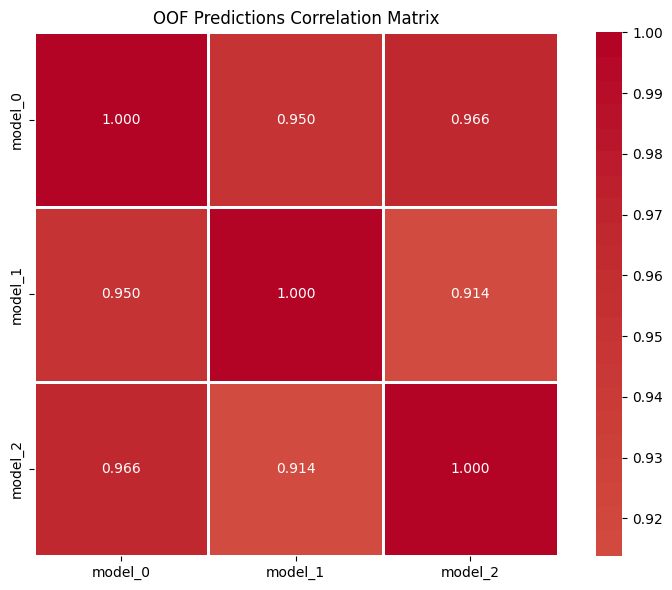

[I 2025-08-16 19:43:00,977] A new study created in memory with name: no-name-4e31f720-1e1c-4579-84ea-5a81ad6e4281
[I 2025-08-16 19:43:00,978] Trial 0 finished with value: -10000000000.0 and parameters: {'weight_0': 0.38642542860184637, 'weight_1': 0.6461248403104131}. Best is trial 0 with value: -10000000000.0.
[I 2025-08-16 19:43:00,980] Trial 1 finished with value: 0.0 and parameters: {'weight_0': 0.5239550458370683, 'weight_1': 0.32937057207892106}. Best is trial 1 with value: 0.0.
[I 2025-08-16 19:43:00,981] Trial 2 finished with value: 0.0 and parameters: {'weight_0': 0.5066886317106783, 'weight_1': 0.4786103758067455}. Best is trial 1 with value: 0.0.
[I 2025-08-16 19:43:00,982] Trial 3 finished with value: 0.0 and parameters: {'weight_0': 0.05606706259003069, 'weight_1': 0.8349079003217773}. Best is trial 1 with value: 0.0.
[I 2025-08-16 19:43:00,983] Trial 4 finished with value: -10000000000.0 and parameters: {'weight_0': 0.7884635030264463, 'weight_1': 0.7685546641385917}. Bes


6.3 Testing ensemble strategies...

  Testing simple average...
    Score: 0.8895

  Testing CV-weighted average...
    Score: 0.8895
    Weights: {'lightgbm': 0.331, 'xgboost': 0.334, 'catboost': 0.335}

  Optimizing weights with Optuna (150 trials)...


[I 2025-08-16 19:43:01,170] Trial 29 finished with value: -10000000000.0 and parameters: {'weight_0': 0.3649892596008153, 'weight_1': 0.6587132090078294}. Best is trial 1 with value: 0.0.
[I 2025-08-16 19:43:01,181] Trial 30 finished with value: 0.0 and parameters: {'weight_0': 0.6972011437477081, 'weight_1': 0.15669372340417176}. Best is trial 1 with value: 0.0.
[I 2025-08-16 19:43:01,191] Trial 31 finished with value: 0.0 and parameters: {'weight_0': 0.44216229117879374, 'weight_1': 0.008270309785212593}. Best is trial 1 with value: 0.0.
[I 2025-08-16 19:43:01,202] Trial 32 finished with value: 0.0 and parameters: {'weight_0': 0.5593831982259598, 'weight_1': 0.0989862769379104}. Best is trial 1 with value: 0.0.
[I 2025-08-16 19:43:01,211] Trial 33 finished with value: -10000000000.0 and parameters: {'weight_0': 0.4506425953621728, 'weight_1': 0.6320038420952512}. Best is trial 1 with value: 0.0.
[I 2025-08-16 19:43:01,221] Trial 34 finished with value: -10000000000.0 and parameters: 

    Score: 0.8897
    Weights: {'lightgbm': 0.524, 'xgboost': 0.329, 'catboost': 0.147}

  Fitting stacking ensemble...
    Score: 0.8901

  Testing rank averaging...
    Score: 0.8896

✓ Best ensemble strategy: stacking (Score: 0.8901)

6.4 Training models on full training data...
  Training lightgbm...
  Training xgboost...
  Training catboost...

6.5 Generating test predictions...

ENSEMBLE RESULTS SUMMARY
       Strategy  OOF Score
       stacking   0.890147
optuna_weighted   0.889742
   rank_average   0.889582
 simple_average   0.889525
    cv_weighted   0.889514


In [8]:
def create_advanced_ensemble(models, X_train, y_train, X_test, cv_scores):
    """Create advanced ensemble with multiple strategies and validation."""
    print("\n" + "="*70)
    print("6. ADVANCED ENSEMBLE CREATION")
    print("="*70)
    
    # Filter models that have cv_scores (successfully trained)
    successful_models = {name: model for name, model in models.items() if name in cv_scores}
    
    if len(successful_models) == 0:
        print("ERROR: No models were successfully trained!")
        return None, None, None, None
    
    print(f"\nUsing {len(successful_models)} successfully trained models out of {len(models)} attempted")
    if len(successful_models) < len(models):
        failed_models = set(models.keys()) - set(successful_models.keys())
        print(f"  Failed models: {failed_models}")
    
    # Create OOF ensemble
    ensemble = OOFEnsemble(task_type='classification', metric='roc_auc')
    
    # Get model list sorted by CV performance
    model_performance = [(name, cv_scores[name]['mean']) for name in successful_models.keys()]
    model_performance.sort(key=lambda x: x[1], reverse=True)
    
    print("\nModel ranking by CV score:")
    for i, (name, score) in enumerate(model_performance, 1):
        print(f"  {i}. {name}: {score:.4f}")
    
    model_list = list(successful_models.values())
    
    # Generate OOF predictions
    print(f"\n6.1 Generating OOF predictions for {len(model_list)} models...")
    oof_predictions = ensemble.get_oof_predictions(
        models=model_list,
        X=X_train,
        y=y_train,
        n_folds=5,
        stratified=True,
        verbose=True
    )
    
    # Check if OOF scores are all 0 (indicates a problem)
    oof_means = oof_predictions.mean()
    if (oof_means == 0).all():
        print("\n⚠️ Warning: All OOF predictions appear to be 0. This may indicate an issue with the models.")
        print("Continuing anyway, but results may be incorrect.")
    
    # Analyze OOF predictions correlation
    print("\n6.2 Analyzing model predictions correlation...")
    oof_corr = oof_predictions.corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(oof_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0.5,
                square=True, linewidths=1)
    plt.title('OOF Predictions Correlation Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'oof_correlation.png'), dpi=100, bbox_inches='tight')
    plt.show()
    
    # Test different ensemble strategies
    print("\n6.3 Testing ensemble strategies...")
    
    ensemble_results = {}
    
    # Strategy 1: Simple average
    print("\n  Testing simple average...")
    simple_avg_pred = oof_predictions.mean(axis=1)
    simple_score = roc_auc_score(y_train, simple_avg_pred)
    ensemble_results['simple_average'] = simple_score
    print(f"    Score: {simple_score:.4f}")
    
    # Strategy 2: Weighted by CV scores
    print("\n  Testing CV-weighted average...")
    cv_weights = np.array([cv_scores[name]['mean'] for name in successful_models.keys()])
    cv_weights = cv_weights / cv_weights.sum()
    weighted_pred = np.average(oof_predictions.values, weights=cv_weights, axis=1)
    weighted_score = roc_auc_score(y_train, weighted_pred)
    ensemble_results['cv_weighted'] = weighted_score
    print(f"    Score: {weighted_score:.4f}")
    print(f"    Weights: {dict(zip(successful_models.keys(), cv_weights.round(3)))}")
    
    # Strategy 3: Optimized weights
    print("\n  Optimizing weights with Optuna (150 trials)...")
    try:
        optuna_weights = ensemble.optimize_weights(
            oof_predictions, y_train,
            method='optuna',
            n_trials=150
        )
        optuna_pred = np.average(oof_predictions.values, weights=optuna_weights, axis=1)
        optuna_score = roc_auc_score(y_train, optuna_pred)
        ensemble_results['optuna_weighted'] = optuna_score
        print(f"    Score: {optuna_score:.4f}")
        print(f"    Weights: {dict(zip(successful_models.keys(), optuna_weights.round(3)))}")
    except Exception as e:
        print(f"    Error in Optuna optimization: {str(e)}")
        optuna_weights = None
    
    # Strategy 4: Stacking
    print("\n  Fitting stacking ensemble...")
    try:
        # Import LogisticRegression for meta-model
        from sklearn.linear_model import LogisticRegression
        
        # Create a new ensemble for stacking
        stacking_ensemble = OOFEnsemble(task_type='classification')
        
        # Use actual LogisticRegression model object
        meta_model = LogisticRegression(random_state=42, max_iter=1000)
        stacking_ensemble.fit_stacking(oof_predictions, y_train, meta_model=meta_model)
        
        stacking_pred = stacking_ensemble.predict_stacking(oof_predictions)
        stacking_score = roc_auc_score(y_train, stacking_pred)
        ensemble_results['stacking'] = stacking_score
        print(f"    Score: {stacking_score:.4f}")
    except Exception as e:
        print(f"    Error in stacking: {str(e)}")
        print("    Skipping stacking strategy...")
        stacking_ensemble = None
    
    # Strategy 5: Rank averaging
    print("\n  Testing rank averaging...")
    rank_pred = ensemble.rank_average([oof_predictions[col].values for col in oof_predictions.columns])
    rank_score = roc_auc_score(y_train, rank_pred)
    ensemble_results['rank_average'] = rank_score
    print(f"    Score: {rank_score:.4f}")
    
    # Select best strategy
    if len(ensemble_results) > 0:
        best_strategy = max(ensemble_results.items(), key=lambda x: x[1])
        print(f"\n✓ Best ensemble strategy: {best_strategy[0]} (Score: {best_strategy[1]:.4f})")
    else:
        print("\n⚠️ No ensemble strategies succeeded. Using simple average as fallback.")
        best_strategy = ('simple_average', 0.5)
    
    # Train models on full data
    print("\n6.4 Training models on full training data...")
    for name, model in successful_models.items():
        print(f"  Training {name}...")
        model.fit(X_train, y_train)
    
    # Generate test predictions
    print("\n6.5 Generating test predictions...")
    test_predictions = ensemble.get_test_predictions(model_list, X_test)
    
    # Apply best strategy for final predictions
    if best_strategy[0] == 'simple_average':
        final_predictions = test_predictions.mean(axis=1)
    elif best_strategy[0] == 'cv_weighted':
        final_predictions = np.average(test_predictions.values, weights=cv_weights, axis=1)
    elif best_strategy[0] == 'optuna_weighted' and optuna_weights is not None:
        final_predictions = np.average(test_predictions.values, weights=optuna_weights, axis=1)
    elif best_strategy[0] == 'stacking' and stacking_ensemble is not None:
        final_predictions = stacking_ensemble.predict_stacking(test_predictions)
    else:  # rank_average or fallback
        final_predictions = ensemble.rank_average([test_predictions[col].values for col in test_predictions.columns])
    
    # Also keep simple average for comparison
    simple_predictions = test_predictions.mean(axis=1)
    
    # Display ensemble results summary
    print("\n" + "="*50)
    print("ENSEMBLE RESULTS SUMMARY")
    print("="*50)
    if len(ensemble_results) > 0:
        results_df = pd.DataFrame({
            'Strategy': list(ensemble_results.keys()),
            'OOF Score': list(ensemble_results.values())
        }).sort_values('OOF Score', ascending=False)
        print(results_df.to_string(index=False))
    else:
        print("No ensemble strategies completed successfully.")
    
    return final_predictions, simple_predictions, ensemble, best_strategy[0]

# Create advanced ensemble
final_predictions, simple_predictions, ensemble, best_strategy = create_advanced_ensemble(
    models, X_train_selected, y_train, X_test_selected, cv_scores
)

# Check if ensemble creation was successful
if final_predictions is None:
    print("\nERROR: Ensemble creation failed. Please check model training errors above.")
    print("Skipping submission generation...")

## 7. Generate and Validate Submissions

In [9]:
def generate_validated_submission(predictions, test_ids, submission_df, name="submission"):
    """Generate submission with validation checks."""
    print(f"\nGenerating {name}...")
    
    # Convert predictions to numpy array if it's a pandas Series
    if hasattr(predictions, 'values'):
        predictions = predictions.values
    
    # Validate predictions
    assert len(predictions) == len(test_ids), f"Prediction length mismatch! Predictions: {len(predictions)}, IDs: {len(test_ids)}"
    assert not np.isnan(predictions).any(), "Predictions contain NaN values!"
    assert (predictions >= 0).all() and (predictions <= 1).all(), "Predictions out of [0,1] range!"
    
    # Convert probabilities to boolean
    predictions_bool = (predictions > 0.5)
    
    # Create submission dataframe
    submission = pd.DataFrame({
        'PassengerId': test_ids.values if hasattr(test_ids, 'values') else test_ids,
        'Transported': predictions_bool
    })
    
    # Ensure correct format
    submission['Transported'] = submission['Transported'].map({True: 'True', False: 'False'})
    
    # Sort by PassengerId to match submission_df order
    submission = submission.sort_values('PassengerId')
    submission_df_sorted = submission_df.sort_values('PassengerId')
    
    # Validate submission format (comparing sorted versions)
    assert len(submission) == len(submission_df), f"Submission length mismatch! Got {len(submission)}, expected {len(submission_df)}"
    assert set(submission['PassengerId']) == set(submission_df['PassengerId']), "PassengerId sets don't match!"
    assert submission['Transported'].isin(['True', 'False']).all(), "Invalid Transported values!"
    
    # Reorder to match original submission_df order
    submission = submission.set_index('PassengerId').loc[submission_df['PassengerId']].reset_index()
    
    # Save submission
    submission_path = os.path.join(OUTPUT_DIR, f'{name}.csv')
    submission.to_csv(submission_path, index=False)
    print(f"  ✓ Saved to '{submission_path}'")
    
    # Display statistics
    print(f"\n  Prediction distribution:")
    dist = submission['Transported'].value_counts(normalize=True)
    print(f"    True:  {dist.get('True', 0):.2%}")
    print(f"    False: {dist.get('False', 0):.2%}")
    
    print(f"\n  Sample predictions (first 10):")
    print(submission.head(10).to_string(index=False))
    
    return submission

# Only generate submissions if ensemble was successful
if final_predictions is not None:
    # Generate submissions
    print("\n" + "="*70)
    print("7. GENERATING VALIDATED SUBMISSIONS")
    print("="*70)

    # Best ensemble submission
    submission_best = generate_validated_submission(
        final_predictions, test_ids, submission_df, 
        name=f"submission_best_{best_strategy}"
    )

    # Simple average submission (backup)
    submission_simple = generate_validated_submission(
        simple_predictions, test_ids, submission_df, 
        name="submission_simple_avg"
    )

    print("\n" + "="*70)
    print("✓ All submissions generated successfully!")
    print("="*70)
else:
    print("\n" + "="*70)
    print("7. SUBMISSION GENERATION SKIPPED")
    print("="*70)
    print("Cannot generate submissions because ensemble creation failed.")
    print("Please fix model training issues and re-run the notebook.")


7. GENERATING VALIDATED SUBMISSIONS

Generating submission_best_stacking...
  ✓ Saved to '/kaggle/working/submission_best_stacking.csv'

  Prediction distribution:
    True:  50.97%
    False: 49.03%

  Sample predictions (first 10):
PassengerId Transported
    0013_01       False
    0018_01       False
    0019_01        True
    0021_01        True
    0023_01        True
    0027_01        True
    0029_01        True
    0032_01        True
    0032_02        True
    0033_01        True

Generating submission_simple_avg...
  ✓ Saved to '/kaggle/working/submission_simple_avg.csv'

  Prediction distribution:
    True:  51.60%
    False: 48.40%

  Sample predictions (first 10):
PassengerId Transported
    0013_01       False
    0018_01       False
    0019_01        True
    0021_01        True
    0023_01        True
    0027_01        True
    0029_01        True
    0032_01        True
    0032_02        True
    0033_01        True

✓ All submissions generated successfully!


## 8. Final Summary and Next Steps

In [10]:
print("\n" + "="*70)
print("COMPETITION SOLUTION COMPLETE!")
print("="*70)

print("""
📊 RESULTS SUMMARY
==================
""")

print(f"• Models trained: {len(models)}")
if cv_scores:
    for name, scores in cv_scores.items():
        print(f"  - {name}: CV={scores['mean']:.4f} (+/- {scores['std']:.4f})")
else:
    print("  ⚠️ No models were successfully trained with CV scores")

if final_predictions is not None:
    print(f"\n• Best ensemble strategy: {best_strategy}")
    print(f"• Total features used: {X_train_selected.shape[1]}")
    print(f"• Submissions generated: 2")
    
    print("""
📁 FILES CREATED
================
""")
    print(f"• submission_best_{best_strategy}.csv - Best performing ensemble")
    print(f"• submission_simple_avg.csv - Simple average baseline")
    print(f"• comprehensive_eda.png - EDA visualizations")
    print(f"• feature_importance.png - Top feature importances")
    print(f"• oof_correlation.png - Model predictions correlation")
else:
    print("\n⚠️ Ensemble creation failed - no submissions generated")
    print("• Please check model training errors above")
    print("• Ensure TabML is properly installed with all dependencies")

print("""
🚀 NEXT STEPS
=============
1. Submit the best ensemble to Kaggle
2. Try these improvements:
   • Add more domain-specific features
   • Experiment with neural network architectures
   • Try pseudo-labeling with high-confidence predictions
   • Implement adversarial validation
   • Use external data if allowed
3. Analyze error patterns:
   • Review misclassified examples
   • Look for data leakage opportunities
   • Check for temporal patterns
""")

print("\n" + "="*70)
if final_predictions is not None:
    print("✅ Pipeline execution completed successfully!")
    print("🎯 Good luck with the competition!")
else:
    print("⚠️ Pipeline execution completed with errors")
    print("Please fix the issues and re-run the notebook")
print("="*70)


COMPETITION SOLUTION COMPLETE!

📊 RESULTS SUMMARY

• Models trained: 3
  - lightgbm: CV=0.8812 (+/- 0.0060)
  - xgboost: CV=0.8900 (+/- 0.0055)
  - catboost: CV=0.8904 (+/- 0.0056)

• Best ensemble strategy: stacking
• Total features used: 48
• Submissions generated: 2

📁 FILES CREATED

• submission_best_stacking.csv - Best performing ensemble
• submission_simple_avg.csv - Simple average baseline
• comprehensive_eda.png - EDA visualizations
• feature_importance.png - Top feature importances
• oof_correlation.png - Model predictions correlation

🚀 NEXT STEPS
1. Submit the best ensemble to Kaggle
2. Try these improvements:
   • Add more domain-specific features
   • Experiment with neural network architectures
   • Try pseudo-labeling with high-confidence predictions
   • Implement adversarial validation
   • Use external data if allowed
3. Analyze error patterns:
   • Review misclassified examples
   • Look for data leakage opportunities
   • Check for temporal patterns


✅ Pipeline ex